<h1 style="text-align: center; font-size: 40px; color: gray; font-weight: 700; margin-bottom: 5px;">
    CAPSTONE PROJECT 3
</h1>
<h2 style="text-align: center; font-weight: 500; margin-top: 0;">
    Use Case : Shopee
</h2>

# **Outline**

- [**Section 0.** Import Library](#import-library)
- [**Section 1.** Business Understanding](#business-understanding)
- [**Section 2.** Data Understanding](#data-understanding)
- [**Section 3.** Data Cleaning](#data-cleaning)
- [**Section 4.** Feature Generation](#feature-generation)
- [**Section 5.** Data Anlysis](#data-analysis)
- [**Section 6.** Kesimpulan dan Rekomendasi](#kesimpulan-dan-rekomendasi)


# **IMPORT LIBRARY**



In [ ]:
# Basic Libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as sc
import matplotlib.ticker as mtick

#Ignore Warning
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid')
pd.set_option('display.max_columns', None)

# **BUSINESS UNDERSTANDING**

## **1. BACKGROUND**

Shopee telah berhasil merajai pasar e-commerce di Asia Tenggara melalui strategi pemasaran
yang agresif, khususnya kampanye tanggal kembar (11.11, 12.12) dan fitur gamification seperti
Shopee Tanam atau Shopee Candy. Ekosistem ini dirancang secara khusus untuk
meningkatkan Daily Active Users (DAU) dan menjaga pengguna agar menghabiskan waktu
lebih lama di dalam aplikasi. Sebagai reward, pengguna diberikan Shopee Coins dan berbagai
macam voucher (Gratis Ongkir, Cashback) yang bisa ditumpuk (stacking) saat checkout.

Daya tarik utama lainnya adalah program Flash Sale, di mana barang-barang bernilai tinggi
(seperti iPhone atau TV) dijual dengan harga ekstrem, misalnya Rp 1. Program ini sangat
sukses menciptakan hype dan mendatangkan traffic masif dalam waktu singkat. Namun, traffic
yang tinggi ini ternyata tidak berbanding lurus dengan kualitas konversi. Tim Anti-Fraud mulai
mendeteksi bahwa barang-barang Flash Sale seringkali habis dalam waktu kurang dari 1 detik.

Usut punya usut, sistem Shopee dibanjiri oleh aktivitas bot (skrip otomatis) dan scalper yang
secara sistematis memborong barang Flash Sale untuk dijual kembali di platform lain. Hal ini
memicu gelombang protes dari user asli di media sosial yang merasa ditipu karena tidak pernah
kebagian barang. Selain merusak citra brand, aktivitas ini membuat subsidi diskon miliaran
rupiah jatuh ke tangan sindikat penipu, bukan ke target konsumen yang sebenarnya.

Masalah semakin runyam di sisi validasi Voucher dan Shopee Coins. Tim Data Engineer
melaporkan adanya kejanggalan pada sistem checkout. Ditemukan banyak transaksi yang
berhasil menggunakan voucher diskon besar, padahal total belanjanya tidak memenuhi syarat
Minimum Spend (Konteks Bisnis Error). Selain itu, pencatatan perangkat pengguna (Device
OS) di database sangat berantakan, membuat tim Security kesulitan melacak Device ID mana
saja yang di-kloning untuk membuat ribuan akun bodong.

Oleh karena itu, analisis mendalam terhadap log transaksi Flash Sale, penggunaan voucher,
dan pergerakan Shopee Coins ini sangat mendesak untuk dieksekusi. Tanpa adanya
pembersihan data dan identifikasi pola bot secara komprehensif, Shopee akan terus
"membakar uang" untuk mensubsidi sindikat fraudster, sementara pengguna asli (real users)
justru perlahan-lahan churn karena kehilangan kepercayaan terhadap platform. Analisis ini
adalah kunci untuk menyelamatkan budget promosi perusahaan.

## **2. PROBLEM STATEMENT**

**Masalah Utama:** Kerugian finansial dan menurunnya kepercayaan pengguna asli akibat
aktivitas Bot/Scalper pada Flash Sale serta penyalahgunaan (abuse) sistem Voucher dan
Shopee Coins.

**Masalah Turunan:**
1. Bagaimana pola durasi checkout (dari masuk keranjang hingga bayar) yang
mengindikasikan transaksi tersebut dilakukan oleh bot/script?

2. Berapa estimasi kerugian dari kebocoran sistem di mana Voucher berhasil dipakai
padahal transaksi tidak memenuhi syarat Minimum Spend?
3. Device ID mana saja yang terafiliasi dengan ratusan akun berbeda (indikasi farm
account)?
4. Seberapa berantakan pencatatan Device OS di sistem, dan bagaimana cara
menstandarisasinya untuk kebutuhan analisis perangkat fraud?
5. Berapa banyak anomali/outliers di mana user me-redeem (menukarkan) Shopee Coins
melebihi batas saldo wajar atau bahkan bernilai negatif?
6. Apakah ada korelasi antara metode pembayaran tertentu (misal: Transfer Bank Manual)
dengan tingkat keberhasilan transaksi bot di Flash Sale?

## **3. GOALS**

Tujuan utama dari analisis ini adalah untuk menyelamatkan anggaran promosi dan meningkatkan integritas platform:

**Bot Mitigation:** Membangun aturan atau model otomatis untuk memblokir transaksi dengan durasi checkout di bawah standar manusia.

**System Patching:** Mengidentifikasi celah (bug) pada sistem validasi transaksi agar penggunaan voucher tepat sasaran sesuai syarat belanja.

**Data Cleansing:** Menghasilkan tabel referensi Device OS yang bersih untuk mempermudah operasional tim Anti-Fraud.

**Budget Optimization:** Memastikan dana pemasaran (Koin & Voucher) hanya dinikmati oleh pengguna asli untuk menyehatkan metrik retensi dan Customer Loyalty Value (CLV).

## **4. ANALYTICAL APPROACH**

Analisis ini bertujuan untuk mengidentifikasi aktivitas bot pada Flash Sale, penyalahgunaan voucher dan Shopee Coins, serta pola fraud berbasis device dan masalah kualitas data. Pendekatan yang digunakan meliputi rule-based fraud detection untuk mendeteksi perilaku tidak wajar (seperti checkout terlalu cepat dan misuse voucher), exploratory data analysis (EDA) untuk menemukan pola dan anomali, serta data cleaning untuk menstandarisasi data seperti device OS.

Analisis dilakukan melalui proses data preparation, feature engineering (misalnya pembuatan flag is_bot, voucher_bug, dan coins_anomaly), serta agregasi dan visualisasi data. Hasil yang diharapkan adalah insight terkait tingkat fraud dan estimasi kerugian, serta rekomendasi bisnis untuk meningkatkan validasi sistem dan efektivitas penggunaan budget promosi. Pendekatan ini juga dapat dikembangkan lebih lanjut menjadi model machine learning untuk fraud detection secara real-time.

# **DATA UNDERSTANDING**

## **1. DESKRIPSI DATASET**

- Sumber dataset: Data simulasi transaksi e-commerce Shopee (internal  dataset untuk analisis fraud).

- Jumlah baris: 300.000 (pada tabel orders).
- Jumlah tabel: 3 tabel utama (users, vouchers, orders).
- Tipe problem: Fraud detection & anomaly analysis (rule-based analysis).

Note:
- Dataset terdiri dari data pengguna, transaksi, dan voucher yang saling terhubung.
- Analisis difokuskan untuk mengidentifikasi aktivitas bot, abuse sistem, serta pola fraud berbasis device.

### Struktur Dataset

1. **Users Dataset (shopee_users)**

| Nama Kolom | Tipe Data | Deskripsi |
| :--- | :--- | :--- |
| **`user_id`** | Kategorikal | ID unik untuk setiap pengguna |
| **`device_id`** | Kategorikal | ID perangkat yang digunakan oleh pengguna |
| **`device_os`** | Kategorikal | Sistem operasi perangkat (Android, iOS, dll.) |
| **`coins_balance`** | Numerik |Saldo Shopee Coins yang dimiliki pengguna |

2. **Vouchers Dataset (shopee_vouchers)**

| Nama Kolom | Tipe Data | Deskripsi |
| :--- | :--- | :--- |
| **`voucher_code`** | Kategorikal | Kode unik voucher |
| **`voucher_type`** | Kategorikal | Jenis voucher (Gratis Ongkir, Cashback, Diskon) |
| **`min_spend`** | Numerik | Minimum transaksi agar voucher dapat digunakan |
| **`discount_amount`** | Numerik | Nilai diskon yang diberikan oleh voucher |

3. **Orders Dataset (shopee_orders)**

| Nama Kolom | Tipe Data | Deskripsi |
| :--- | :--- | :--- |
| **`order_id`** | Kategorikal | ID unik untuk setiap transaksi |
| **`user_id`** | Kategorikal | ID unik untuk setiap pengguna |
| **`order_time`** | Kategorikal | Waktu transaksi dilakukan |
|**`is_flash_sale`** | Binary | Status apakah transaksi terjadi saat Flash Sale (YES/NO) |
| **`checkout_duration_sec`** | Numerik | Durasi checkout dari keranjang ke pembayaran (dalam detik) |
| **`total_amount`** | Numerik | Total nilai transaksi sebelum diskon |
| **`voucher_code`** | Kategorikal | Kode voucher yang digunakan (jika ada) |
| **`coins_redeemed`** | Numerik | Jumlah Shopee Coins yang digunakan dalam transaksi |



## **2. DATASET PREVIEW**

In [ ]:
# Load Dataset

order = pd.read_csv("shopee_orders.csv")
user = pd.read_csv("shopee_users.csv")
voucher = pd.read_csv("shopee_vouchers.csv")


In [ ]:
# Menggabungkan Dataset

df = pd.merge(order, user, on= 'user_id', how= 'left')
df_merge = pd.merge(df, voucher, on= 'voucher_code', how='left')

df_merge.sample(5)

,order_id,user_id,order_time,is_flash_sale,checkout_duration_sec,total_amount,voucher_code,coins_redeemed,device_id,device_os,coins_balance,voucher_type,min_spend,discount_amount
284451,ORD-SHP-0284452,SHP-013740,2023-11-28 09:47:00,True,12.68,1895712,VCH094SALE,1000,DEV-05000,android,29589,Diskon 50%,120000.0,16569.0
107767,ORD-SHP-0107768,SHP-019562,2023-11-27 02:57:00,False,238.11,1629134,VCH062SALE,0,DEV-01442,ANDROID,48323,Cashback 10%,0.0,41514.0
25103,ORD-SHP-0025104,SHP-013364,2023-11-30 10:56:00,False,31.86,462144,VCH055SALE,1000,DEV-02026,Android,21309,Cashback 10%,30000.0,17868.0
78127,ORD-SHP-0078128,SHP-008176,2023-11-01 01:15:00,False,168.20,1188848,VCH034SALE,0,DEV-08697,Android,17374,Cashback 10%,300000.0,41071.0
157941,ORD-SHP-0157942,SHP-013535,2023-11-17 20:16:00,False,84.16,1238262,NaN,0,DEV-06420,android,30181,NaN,NaN,NaN


In [ ]:
# Dataset General Information

df_merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               300000 non-null  object 
 1   user_id                300000 non-null  object 
 2   order_time             300000 non-null  object 
 3   is_flash_sale          300000 non-null  bool   
 4   checkout_duration_sec  300000 non-null  float64
 5   total_amount           300000 non-null  int64  
 6   voucher_code           150000 non-null  object 
 7   coins_redeemed         300000 non-null  int64  
 8   device_id              290947 non-null  object 
 9   device_os              300000 non-null  object 
 10  coins_balance          300000 non-null  int64  
 11  voucher_type           150000 non-null  object 
 12  min_spend              150000 non-null  float64
 13  discount_amount        150000 non-null  float64
dtypes: bool(1), float64(3), int64(3), ob

Missing values pada voucher_code, voucher_type, min_spend, dan discount_amount mengindikasikan bahwa tidak semua transaksi menggunakan voucher. Selain itu, terdapat juga sedikit missing value pada kolom device_id.

In [ ]:
# Statistical Summary

df_merge.describe()

,checkout_duration_sec,total_amount,coins_redeemed,coins_balance,min_spend,discount_amount
count,300000.000000,3.000000e+05,3.000000e+05,300000.000000,150000.00000,150000.000000
mean,149.843933,9.857695e+05,2.449420e+06,24922.189890,111924.20000,26983.378687
std,86.622502,5.848057e+05,3.490231e+07,14458.978728,115036.84487,13271.178661
min,0.100000,1.000000e+03,-9.999000e+03,2.000000,0.00000,6615.000000
25%,74.620000,4.743948e+05,0.000000e+00,12292.000000,30000.00000,14376.000000
50%,149.860000,9.860440e+05,0.000000e+00,24938.000000,50000.00000,27150.000000
75%,224.960000,1.493640e+06,1.000000e+03,37529.000000,300000.00000,38158.000000
max,300.000000,1.999988e+06,5.000000e+08,49996.000000,300000.00000,49948.000000


Rata-rata durasi checkout berada di sekitar 149 detik, dengan nilai minimum sangat kecil (0.1 detik) yang mengindikasikan kemungkinan aktivitas bot atau otomatisasi.

Pada fitur coins_redeemed, ditemukan nilai minimum negatif  dan nilai maksimal yang sangat besar, yang mengindikasikan adanya anomali atau error dalam sistem penggunaan koin.

# **DATA CLEANING**

## **1. DATA TYPE**

In [ ]:
# Konversi Tipe Data Pada Kolom `order_time`

df_merge['order_time'] = pd.to_datetime(df_merge['order_time'])

In [ ]:
df_merge['min_spend'] = df_merge['min_spend'].astype('Int64')

In [ ]:
df_merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   order_id               300000 non-null  object        
 1   user_id                300000 non-null  object        
 2   order_time             300000 non-null  datetime64[ns]
 3   is_flash_sale          300000 non-null  bool          
 4   checkout_duration_sec  300000 non-null  float64       
 5   total_amount           300000 non-null  int64         
 6   voucher_code           150000 non-null  object        
 7   coins_redeemed         300000 non-null  int64         
 8   device_id              290947 non-null  object        
 9   device_os              300000 non-null  object        
 10  coins_balance          300000 non-null  int64         
 11  voucher_type           150000 non-null  object        
 12  min_spend              150000 non-null  Int6

## **2. MISSING VALUE**

In [ ]:
# Cek Missing Value

(df_merge.isna().sum()/len(df_merge)*100).sort_values(ascending=False)

,0
discount_amount,50.000000
voucher_code,50.000000
voucher_type,50.000000
min_spend,50.000000
device_id,3.017667
order_id,0.000000
total_amount,0.000000
checkout_duration_sec,0.000000
is_flash_sale,0.000000
order_time,0.000000


In [ ]:
df_merge.isnull().sum().sort_values(ascending=False)

,0
discount_amount,150000
voucher_code,150000
voucher_type,150000
min_spend,150000
device_id,9053
order_id,0
total_amount,0
checkout_duration_sec,0
is_flash_sale,0
order_time,0


Missing Value pada kolom `discount_amount`,`voucher_code`,`voucher_type`,`min_spend` sebesar 50% atau sebanyak 150000, dan Missing Values pada kolom `device_id` sebesar 3% atau sebanyak 9053 data.


In [ ]:
# Handle Missing Value

fill_values = {
    'discount_amount': 0,
    'voucher_code': 'No Voucher',
    'voucher_type': 'No Promo',
    'min_spend': 0
}

df_merge.fillna(value=fill_values, inplace=True)

In [ ]:
df_merge['device_id'] = df_merge['device_id'].fillna('Unknown')

In [ ]:
df_merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   order_id               300000 non-null  object        
 1   user_id                300000 non-null  object        
 2   order_time             300000 non-null  datetime64[ns]
 3   is_flash_sale          300000 non-null  bool          
 4   checkout_duration_sec  300000 non-null  float64       
 5   total_amount           300000 non-null  int64         
 6   voucher_code           300000 non-null  object        
 7   coins_redeemed         300000 non-null  int64         
 8   device_id              300000 non-null  object        
 9   device_os              300000 non-null  object        
 10  coins_balance          300000 non-null  int64         
 11  voucher_type           300000 non-null  object        
 12  min_spend              300000 non-null  Int6

Data dengan Missing Value diisi dengan menambahkan value berupa label 'No Voucher', 'No Promo', 0, dan Unknown. Karena jika dihapus maka hasil analisa bisa akan menjadi bias.

## **3. DATA DUPLICATE**

In [ ]:
# Cek Duplikat Data
duplicate_count = df_merge.duplicated().sum()
duplicate_percent = (duplicate_count / len(df_merge)) * 100
duplicate_rows = df_merge[df_merge.duplicated(keep=False)].sort_values(by=list(df_merge.columns))

print(f"Total Baris Duplikat: {duplicate_count}")
print(f"Persentase dari Total Data: {duplicate_percent:.4f}%")
print("\nSampel Pasangan Data Duplikat:")
display(duplicate_rows)

Total Baris Duplikat: 0
Persentase dari Total Data: 0.0000%

Sampel Pasangan Data Duplikat:


,order_id,user_id,order_time,is_flash_sale,checkout_duration_sec,total_amount,voucher_code,coins_redeemed,device_id,device_os,coins_balance,voucher_type,min_spend,discount_amount


Tidak ditemukan duplikasi data pada dataset.

## **4. OUTLIERS DETECTION**

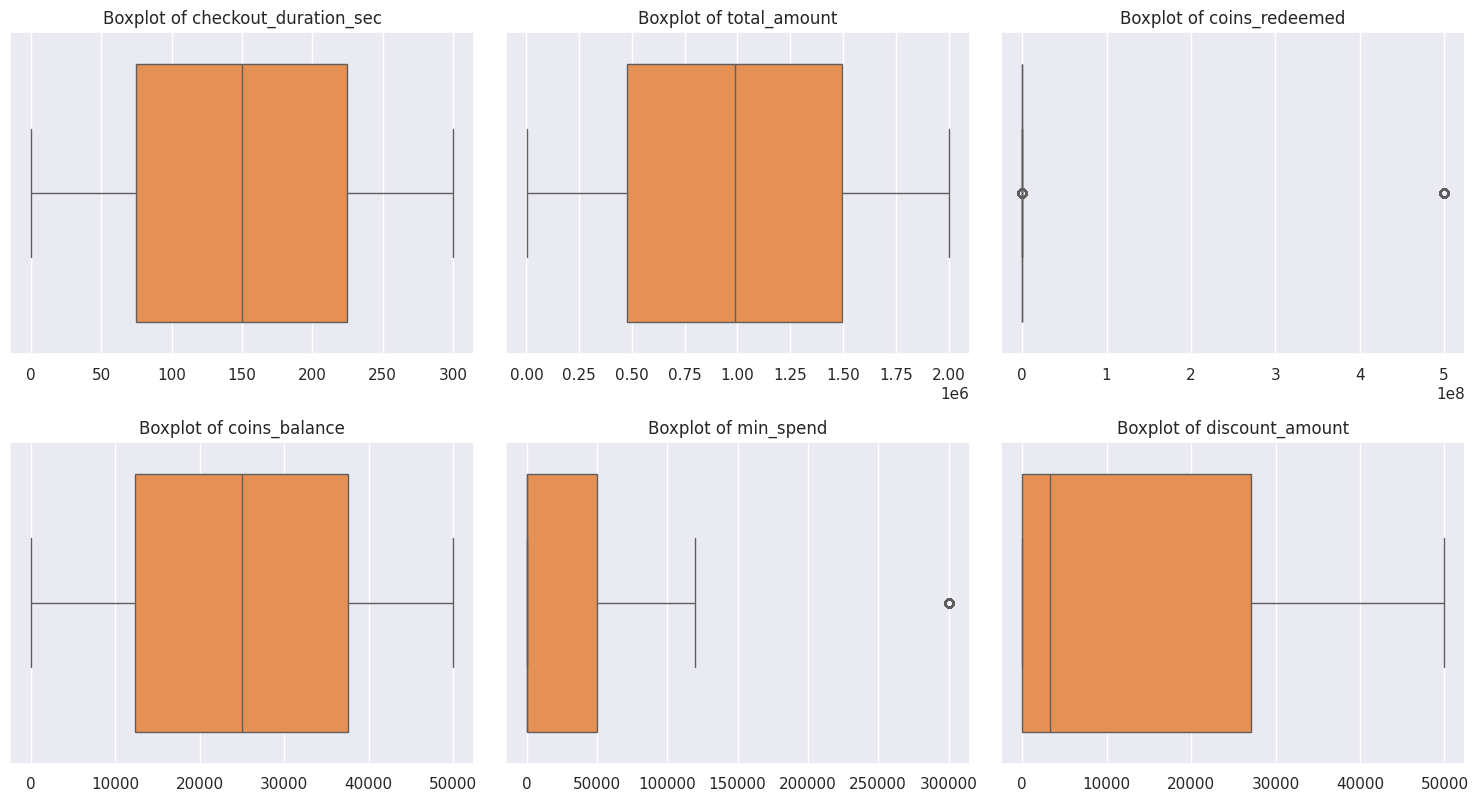

Jumlah Outliers per Kolom (Metode IQR):


,0
checkout_duration_sec,0
total_amount,0
coins_redeemed,47547
coins_balance,0
min_spend,37581
discount_amount,0


In [ ]:
# Check Outliers Feature Numbers (Bukan Kategori Yang Di Buat Numbers)
numeric_cols = ['checkout_duration_sec', 'total_amount', 'coins_redeemed', 'coins_balance', 'min_spend', 'discount_amount']

plt.figure(figsize=(15, 12))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x=df_merge[col], palette='Oranges')
    plt.title(f'Boxplot of {col}')
    plt.xlabel('')

plt.tight_layout()
plt.show()

# Calculate Outlier Counts for Analysis
outlier_report = {}
for col in numeric_cols:
    Q1 = df_merge[col].quantile(0.25)
    Q3 = df_merge[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_merge[(df_merge[col] < lower_bound) | (df_merge[col] > upper_bound)]
    outlier_report[col] = len(outliers)

print("Jumlah Outliers per Kolom (Metode IQR):")
display(pd.Series(outlier_report))

In [ ]:
print(f'coins_redeemed : {df_merge['coins_redeemed'].unique()}')
print(f'min_spend : {df_merge['min_spend'].unique()}')

coins_redeemed : [        0      1000      5000 500000000     10000     -9999]
min_spend : <IntegerArray>
[30000, 0, 300000, 120000, 50000]
Length: 5, dtype: Int64


Berdasarkan analisis visual boxplot dan pemahaman konteks bisnis, tidak semua *outlier* merupakan data yang salah/harus dihapus.

**Rencana Penanganan Outliers**

`coins_redeemed` : hapus outliers pada data asli dan dibuatkan dataframe baru khusus untuk data outliers.

`min_spend` : membiarkan *(Keep)* data outliers dari kolom ini.

In [ ]:
# Membersihkan data dari Outliers yang ada pada kolom 'coins_redeemed'
df_merge_clean = df_merge[(df_merge['coins_redeemed'] < 500000000) & (df_merge['coins_redeemed'] >= 0)]
df_merge_clean.head()

,order_id,user_id,order_time,is_flash_sale,checkout_duration_sec,total_amount,voucher_code,coins_redeemed,device_id,device_os,coins_balance,voucher_type,min_spend,discount_amount
0,ORD-SHP-0000001,SHP-018452,2023-11-14 22:48:00,False,231.09,23737,VCH023SALE,0,DEV-08453,android,36163,Diskon 50%,30000,18403.0
1,ORD-SHP-0000002,SHP-015226,2023-11-20 07:42:00,False,250.47,382011,No Voucher,0,DEV-05988,android,32309,No Promo,0,0.0
2,ORD-SHP-0000003,SHP-008525,2023-11-06 05:04:00,False,100.75,1440505,No Voucher,1000,DEV-07448,iOS,33827,No Promo,0,0.0
3,ORD-SHP-0000004,SHP-007609,2023-11-27 01:00:00,False,159.73,799403,No Voucher,5000,DEV-06821,IOS,39284,No Promo,0,0.0
4,ORD-SHP-0000005,SHP-007025,2023-11-15 09:38:00,False,143.81,303017,No Voucher,0,DEV-03849,android,11332,No Promo,0,0.0


# **FEATURE GENERATION**

## **MEMBUAT KOLOM `is_bot`**



In [ ]:
# Membuat Sebuah Kolom Baru Dari Checkout Duration Sec
anomaly_bot = df_merge_clean['checkout_duration_sec'] < 1

df_merge_clean['is_bot'] = 'No'
df_merge_clean.loc[anomaly_bot, 'is_bot'] = 'Yes'

pd.crosstab(df_merge_clean['is_flash_sale'], df_merge_clean['is_bot'])

is_bot,No,Yes
is_flash_sale,,
False,282225,0
True,11048,3727


Memberikan *(flag)* atau tanda untuk memisahkan transaksi yang mengindikasikan transaksi tersebut dilakukan oleh bot (durasi checkoutnya < 1 detik).

## **MEMBUAT KOLOM `voucher_bug`**

In [ ]:
# Membuat Sebuah Kolom Baru
anomaly_voucher = (df_merge_clean['voucher_code'] != 'No Voucher') & (df_merge_clean['total_amount'] < df_merge_clean['min_spend'])
df_merge_clean['voucher_bug'] = 'No'
df_merge_clean.loc[anomaly_voucher, 'voucher_bug'] = 'Yes'

pd.crosstab(df_merge_clean['is_flash_sale'], df_merge_clean['voucher_bug'])

voucher_bug,No,Yes
is_flash_sale,,
False,269335,12890
True,14089,686


Memberikan *(flag)* atau tanda yg memisahkan transaksi bahwa transaksi tersebut mengalami bug pada voucher (total amount < min spend).

## **MENAMBAHKAN KOLOM `net_revenue`**



In [ ]:
df_merge_clean['net_revenue'] = df_merge_clean['total_amount'] - df_merge_clean['coins_redeemed'] - df_merge_clean['discount_amount']

## **2. FINAL PREVIEW**

In [ ]:
# Tampilan data yang sudah bersih
df_merge_clean.sample(5)

,order_id,user_id,order_time,is_flash_sale,checkout_duration_sec,total_amount,voucher_code,coins_redeemed,device_id,device_os,coins_balance,voucher_type,min_spend,discount_amount,is_bot,voucher_bug,net_revenue
27184,ORD-SHP-0027185,SHP-019823,2023-11-03 21:17:00,False,147.67,976632,VCH066SALE,0,DEV-04171,android,28234,Diskon 50%,300000,18066.0,No,No,958566.0
273728,ORD-SHP-0273729,SHP-002310,2023-11-08 00:41:00,False,63.78,28207,No Voucher,0,DEV-01857,Android,14505,No Promo,0,0.0,No,No,28207.0
176219,ORD-SHP-0176220,SHP-006035,2023-11-18 06:08:00,False,108.06,729259,VCH069SALE,0,DEV-04490,Android,47577,Gratis Ongkir,30000,37303.0,No,No,691956.0
6124,ORD-SHP-0006125,SHP-003325,2023-11-23 19:04:00,False,134.62,1619939,VCH012SALE,0,DEV-02053,iphone,49192,Gratis Ongkir,0,7279.0,No,No,1612660.0
12355,ORD-SHP-0012356,SHP-013653,2023-11-02 17:54:00,False,282.44,114630,No Voucher,1000,DEV-08223,iOS,26515,No Promo,0,0.0,No,No,113630.0


# **DATA ANALYSIS**

## **1. Seberapa berantakan pencatatan Device OS di sistem, dan bagaimana cara menstandarisasinya untuk kebutuhan analisis perangkat fraud?**

In [ ]:
# Mengecek Inkonsistensi Data (Penulisan Kategori)

df_merge_clean['device_os'].value_counts()

,count
device_os,
android,88564
Android,60429
IOS,43956
iOS,29278
WEB,16046
iphone,15314
web browser,14630
ANDROID,14425
mac,14358


In [ ]:
# Handle Inkonsistensi Data (Penulisan Kategori)

df_merge_clean['device_os'] = df_merge_clean['device_os'].str.strip().str.lower()

kat = {
    'iphone' : 'ios',
    'mac' : 'web browser',
    'web' : 'web browser'
}
df_merge_clean['device_os'] = df_merge_clean['device_os'].replace(kat)

df_merge_clean['device_os'].value_counts()

,count
device_os,
android,163418
ios,88548
web browser,45034


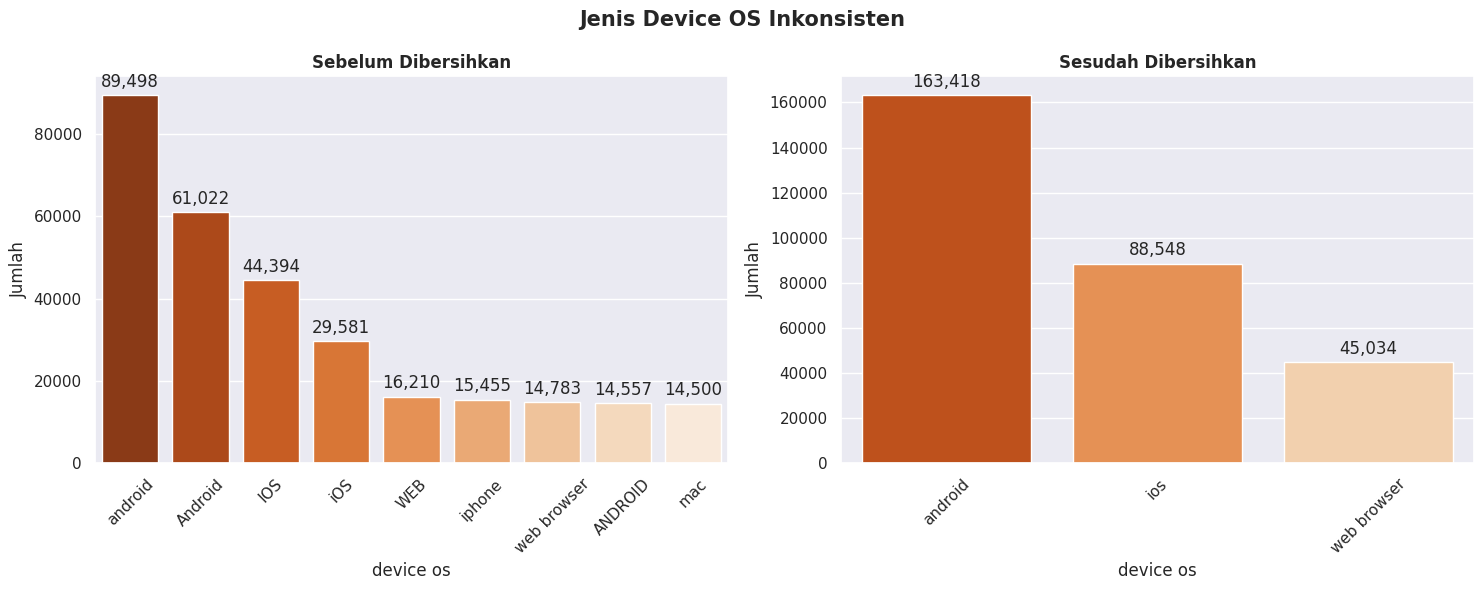

In [ ]:
plt.figure(figsize=(15, 6))
plt.suptitle('Jenis Device OS Inkonsisten', fontsize=15, fontweight='bold')

# Before Cleaning
before = df_merge['device_os'].value_counts(ascending=False).index

ax1 = plt.subplot(1, 2, 1)
sns.countplot(data=df_merge, x='device_os', order=before, palette='Oranges_r')

plt.title('Sebelum Dibersihkan', fontweight='bold')
plt.xticks(rotation=45)
plt.xlabel('device os')
plt.ylabel('Jumlah')

# Menambahkan label
for container in ax1.containers:
    ax1.bar_label(container, fmt='{:,.0f}', padding=3)

# After Cleaning
ax2 = plt.subplot(1, 2, 2)
sns.countplot(data=df_merge_clean, x='device_os', palette='Oranges_r')

plt.title('Sesudah Dibersihkan', fontweight='bold')
plt.xticks(rotation=45)
plt.xlabel('device os')
plt.ylabel('Jumlah')

# Menambahkan label
for container in ax2.containers:
    ax2.bar_label(container, fmt='{:,.0f}', padding=3)

plt.tight_layout()
plt.show()

Berdasarkan analisis `device_os`, ditemukan inkonsistensi yang signifikan dalam pencatatan sistem operasi perangkat. Sebelum pembersihan, terdapat 9 kategori yang berbeda (misalnya, 'android', 'Android' dan sejenisnya). Hal ini menyulitkan analisis karena sistem menganggap 'android' dan 'Android' sebagai kategori terpisah.

Setelah standarisasi, berhasil dirapikan menjadi 3 kategori utama dan konsisten: 'android', 'ios', dan 'web browser'.

**Kesimpulan:** Pencatatan `device_os` awalnya sangat berantakan, namun berhasil distandarisasi untuk memungkinkan analisis yang lebih tepat mengenai pola penggunaan perangkat, yang krusial untuk deteksi *fraud*.

## **2. Berapa banyak anomali/outliers di mana user me-redeem (menukarkan) Shopee Coins melebihi batas saldo wajar atau bahkan bernilai negatif?**

### **Before Cleaning**

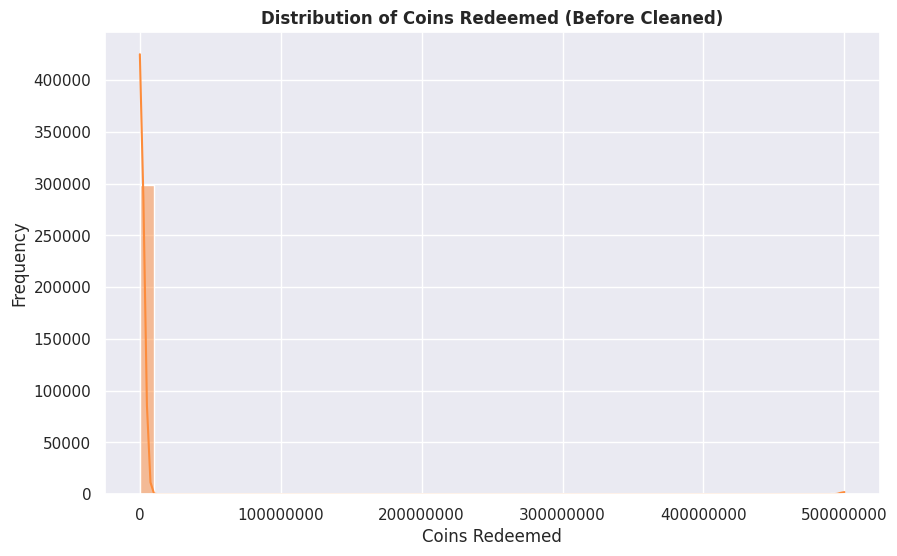

Statistik Deskriptif coins_redeemed:
count    3.000000e+05
mean     2.449420e+06
std      3.490231e+07
min     -9.999000e+03
25%      0.000000e+00
50%      0.000000e+00
75%      1.000000e+03
max      5.000000e+08
Name: coins_redeemed, dtype: float64


In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df_merge['coins_redeemed'], bins=50, kde=True, color=plt.cm.Oranges(0.5))
plt.title('Distribution of Coins Redeemed (Before Cleaned)', fontweight='bold')
plt.xlabel('Coins Redeemed')
plt.ylabel('Frequency')
plt.ticklabel_format(style='plain', axis='x')
plt.show()

# Menampilkan statistik deskriptif untuk kolom tersebut
print("Statistik Deskriptif coins_redeemed:")
print(df_merge['coins_redeemed'].describe())

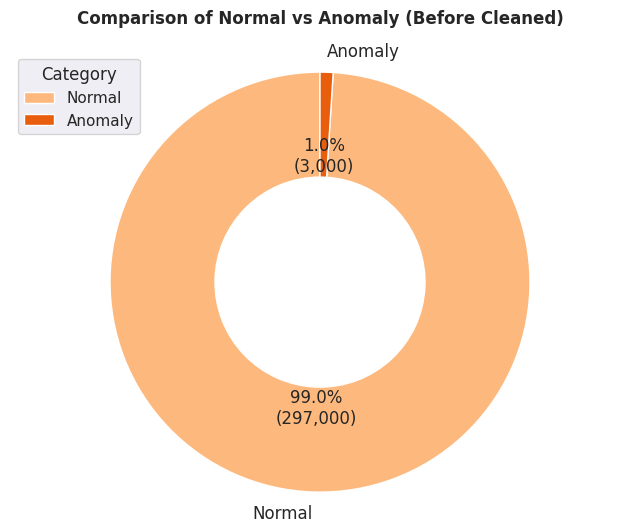

In [ ]:
counts = {
    'Normal': len(df_merge_clean),
    'Anomaly': len(df_merge) - len(df_merge_clean)
}

labels = list(counts.keys())
sizes = list(counts.values())

plt.figure(figsize=(8, 6))

plt.pie(
    sizes,
    labels=labels,
    autopct=lambda pct: f'{pct:.1f}%\n({int(pct*sum(sizes)/100):,})',
    startangle=90,
    wedgeprops=dict(width=0.5),
    colors=sns.color_palette('Oranges', len(labels)),
    textprops={'fontsize': 12}
)

plt.title('Comparison of Normal vs Anomaly (Before Cleaned)',
          fontweight='bold', pad=20)

plt.axis('equal')
plt.legend(title="Category", loc="upper left")
plt.show()

In [ ]:
# Membuat dataframe baru yang berisi Outliers pada kolom 'coins_redeemed'
df_coin_anomaly = df_merge[(df_merge['coins_redeemed'] == 500000000) | (df_merge['coins_redeemed'] == -9999)]
df_coin_anomaly.head()

,order_id,user_id,order_time,is_flash_sale,checkout_duration_sec,total_amount,voucher_code,coins_redeemed,device_id,device_os,coins_balance,voucher_type,min_spend,discount_amount
5,ORD-SHP-0000006,SHP-016912,2023-11-20 11:22:00,False,48.00,386974,No Voucher,500000000,DEV-01407,android,552,No Promo,0,0.0
120,ORD-SHP-0000121,SHP-018718,2023-11-26 00:59:00,False,140.08,241106,No Voucher,-9999,DEV-07688,iOS,39306,No Promo,0,0.0
144,ORD-SHP-0000145,SHP-012742,2023-11-20 08:05:00,False,288.33,661196,No Voucher,-9999,DEV-02628,Android,9910,No Promo,0,0.0
778,ORD-SHP-0000779,SHP-018120,2023-11-30 23:05:00,False,280.44,178026,VCH061SALE,500000000,DEV-03360,mac,9172,Cashback 10%,300000,42992.0
781,ORD-SHP-0000782,SHP-015129,2023-11-22 13:51:00,False,77.73,1444392,VCH049SALE,-9999,DEV-04420,android,33862,Cashback 10%,50000,46518.0


### **After Cleaning**

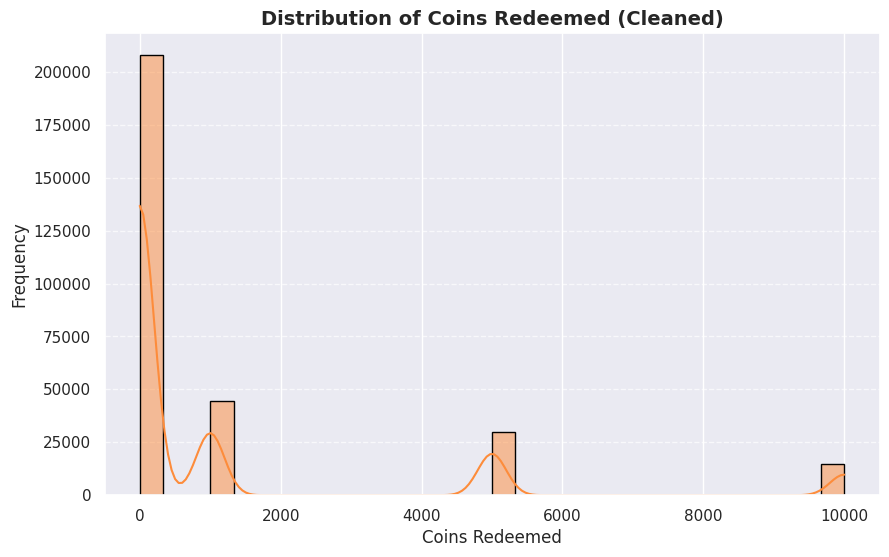

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df_merge_clean['coins_redeemed'], bins=30, kde=True, color=plt.cm.Oranges(0.5), edgecolor='black')
plt.title('Distribution of Coins Redeemed (Cleaned)', fontsize=14, fontweight='bold')
plt.xlabel('Coins Redeemed', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

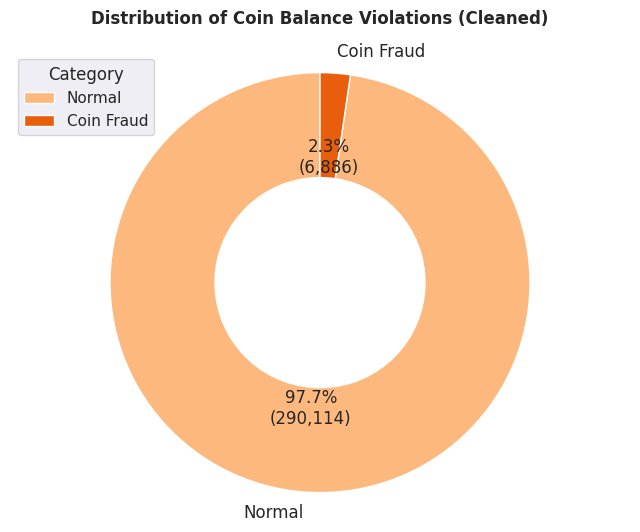

In [ ]:
coin_anomalies = df_merge_clean[df_merge_clean['coins_redeemed'] > df_merge_clean['coins_balance']]

fraud_counts = {'Normal': len(df_merge_clean) - len(coin_anomalies), 'Coin Fraud': len(coin_anomalies)}

plt.figure(figsize=(8, 6))
plt.pie(
    fraud_counts.values(),
    labels=fraud_counts.keys(),
    autopct=lambda p: f'{p:.1f}%\n({int(p*sum(fraud_counts.values())/100):,})',
    colors=sns.color_palette('Oranges', len(fraud_counts)), # Use fraud_counts for labels/colors length
    startangle=90,
    wedgeprops=dict(width=0.5),
    textprops={'fontsize': 12}
)

plt.title('Distribution of Coin Balance Violations (Cleaned)', fontweight='bold', pad=20)
plt.axis('equal') # Ensure the pie chart is circular
plt.legend(title="Category", loc="upper left")
plt.show()

In [ ]:
# Definisikan kondisi anomali koin
anomaly_coin = df_merge_clean['coins_redeemed'] > df_merge_clean['coins_balance']

# Cari baris di mana koin yang dipakai > saldo yang ada
df_fraud_coin = df_merge_clean[anomaly_coin]

print(f"Total Transaksi Mencurigakan: {len(df_fraud_coin)}")
print(df_fraud_coin[['user_id', 'coins_redeemed', 'coins_balance']].head())

# Kerugian dari kebocoran koin
negative_revenue = df_fraud_coin[df_fraud_coin['net_revenue'] < 0]['net_revenue'].sum()
print(f'Total Kebocoran: Rp.{abs(negative_revenue):,.0f}')

Total Transaksi Mencurigakan: 6886
        user_id  coins_redeemed  coins_balance
188  SHP-014996            5000           2614
214  SHP-001819            5000           4962
229  SHP-004895           10000           8392
537  SHP-006300           10000           4843
573  SHP-001887            5000           4508
Total Kebocoran: Rp.2,553,584


Berdasarkan analisis anomali pada kolom `coins_redeemed`, ditemukan 3000 transaksi yang menunjukkan nilai negatif, dan nilai melebihi batas saldo wajar (500.000.000).

Setelah outliers ini dibersihkan, analisis lebih lanjut mengungkapkan 6886 transaksi mencurigakan di mana pengguna menukarkan Shopee Coins melebihi saldo `coins_balance` yang mereka miliki.

**Kesimpulan:** Anomali ini mengindikasikan adanya bug atau celah dalam sistem validasi penggunaan Shopee Coins. Total kerugian finansial yang diakibatkan oleh kebocoran sistem ini sebesar Rp 2.553.584.

### **Diagnostic**

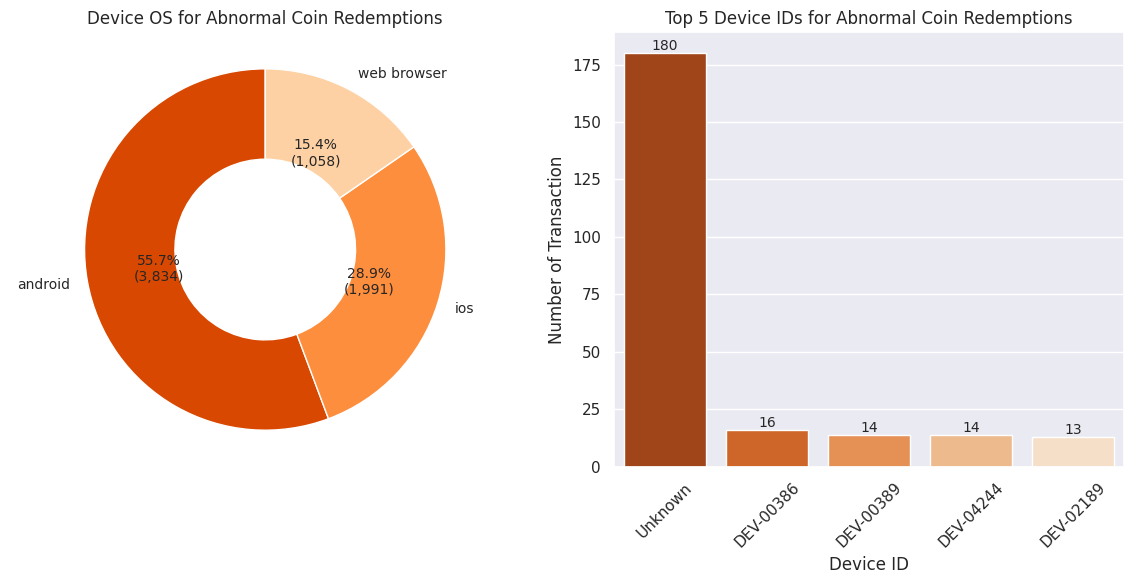

In [ ]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
device_os_counts = df_fraud_coin['device_os'].value_counts()
plt.pie(
    device_os_counts,
    labels=device_os_counts.index,
    autopct=lambda p: f'{p:.1f}%\n({int(p*device_os_counts.sum()/100):,})',
    startangle=90,
    colors=sns.color_palette('Oranges_r', len(device_os_counts)),
    wedgeprops=dict(width=0.5),
    textprops={'fontsize': 10}
)
plt.title('Device OS for Abnormal Coin Redemptions')
plt.axis('equal') # Ensure the pie chart is circular

plt.subplot(1, 2, 2)
top_5_devices = df_fraud_coin['device_id'].value_counts().nlargest(5)
ax2 = sns.barplot(x=top_5_devices.index, y=top_5_devices.values, palette='Oranges_r')
plt.title('Top 5 Device IDs for Abnormal Coin Redemptions')
plt.xlabel('Device ID')
plt.ylabel('Number of Transaction')
plt.xticks(rotation=45)
for p in ax2.patches:
    ax2.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2., p.get_height()), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

Berdasarkan analisis karakteristik pengguna yang melakukan penukaran koin abnormal:

*   **Dominasi Android**: Perangkat Android (sekitar 55% dari total) merupakan sistem operasi yang paling banyak digunakan untuk transaksi penukaran koin abnormal, diikuti oleh iOS dan peramban web.
*   **`device_id` 'Unknown'**: Seperti pada analisis bot, `device_id` 'Unknown' menjadi yang paling dominan di antara transaksi penukaran koin abnormal. Hal ini menunjukkan bahwa pelaku penipuan seringkali menyembunyikan identitas perangkat mereka atau menggunakan metode yang tidak terdeteksi. Beberapa `device_id` spesifik juga muncul di daftar teratas, yang mungkin mengindikasikan penggunaan *farm account* atau perangkat khusus untuk tujuan penipuan.

**Kesimpulan**: Mayoritas penukaran koin abnormal terjadi pada perangkat Android dan seringkali melibatkan `device_id` yang tidak teridentifikasi, mengindikasikan upaya penyembunyian identitas dan kemungkinan penggunaan *farm account*.

## **3. Berapa estimasi kerugian dari kebocoran sistem di mana Voucher berhasil dipakai padahal transaksi tidak memenuhi syarat Minimum Spend?**

In [ ]:
df_merge_clean[df_merge_clean['voucher_bug'] == 'Yes']['order_id'].count()

np.int64(13576)

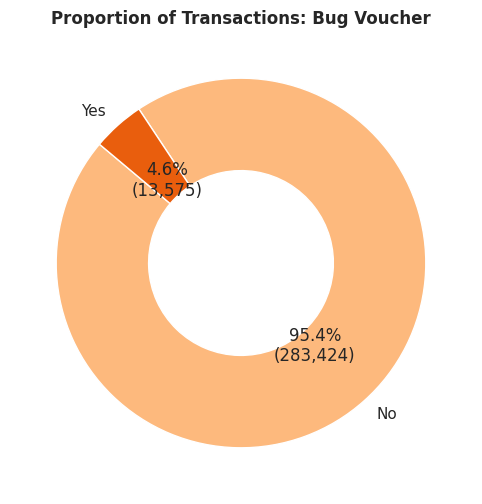

In [ ]:
counts = df_merge_clean['voucher_bug'].value_counts()

plt.figure(figsize=(8, 6))
plt.pie(
    counts,
    labels=counts.index,
    autopct=lambda p: f'{p:.1f}%\n({int(p*sum(counts)/100):,})',
    startangle=140,
    wedgeprops=dict(width=0.5),
    colors=sns.color_palette('Oranges', len(counts))
)

plt.title('Proportion of Transactions: Bug Voucher', fontweight='bold')
plt.show()

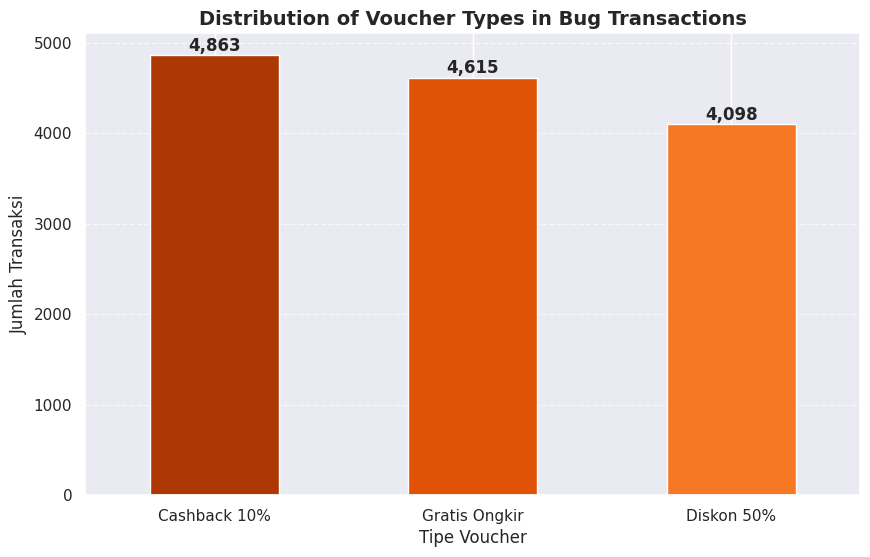

In [ ]:
plt.figure(figsize=(10, 6))
bug_counts = df_merge_clean[df_merge_clean['voucher_bug'] == 'Yes']['voucher_type'].value_counts()

ax = bug_counts.plot(kind='bar', color=sns.color_palette('Oranges_r'))

for i, v in enumerate(bug_counts):
    ax.text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

plt.title('Distribution of Voucher Types in Bug Transactions', fontsize=14, fontweight='bold')
plt.xlabel('Tipe Voucher')
plt.ylabel('Jumlah Transaksi')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
estimated_voucher_loss = df_merge_clean[df_merge_clean['voucher_bug'] == 'Yes']['discount_amount'].sum()

print(f"Estimasi kerugian dari kebocoran voucher: Rp {estimated_voucher_loss:,.2f}")

Estimasi kerugian dari kebocoran voucher: Rp 369,883,390.00


Terdapat 13576 transaksi yang mengalami *voucher bug* dengan estimasi kerugian sebesar Rp 369.883.390,00.

**Kesimpulan:** Jumlah transaksi dengan *voucher bug* dan kerugian finansial menunjukkan adanya celah serius dalam sistem validasi voucher. Perbaikan sistem ini sangat mendesak untuk mencegah kerugian berlanjut dan memastikan anggaran promosi digunakan secara efektif.

### **Diagnostic**

In [ ]:
df_voucher_bug = df_merge_clean[df_merge_clean['voucher_bug'] == 'Yes']
df_voucher_bug.head()

,order_id,user_id,order_time,is_flash_sale,checkout_duration_sec,total_amount,voucher_code,coins_redeemed,device_id,device_os,coins_balance,voucher_type,min_spend,discount_amount,is_bot,voucher_bug,net_revenue
0,ORD-SHP-0000001,SHP-018452,2023-11-14 22:48:00,False,231.09,23737,VCH023SALE,0,DEV-08453,android,36163,Diskon 50%,30000,18403.0,No,Yes,5334.0
9,ORD-SHP-0000010,SHP-017748,2023-11-23 15:02:00,False,178.93,114143,VCH027SALE,0,DEV-08130,ios,21236,Diskon 50%,300000,28042.0,No,Yes,86101.0
40,ORD-SHP-0000041,SHP-017536,2023-11-04 01:35:00,True,0.93,79585,VCH088SALE,0,DEV-03011,android,42949,Cashback 10%,120000,23313.0,Yes,Yes,56272.0
45,ORD-SHP-0000046,SHP-014401,2023-11-15 11:43:00,False,282.31,116430,VCH082SALE,0,DEV-04226,android,8434,Gratis Ongkir,300000,43737.0,No,Yes,72693.0
46,ORD-SHP-0000047,SHP-008047,2023-11-04 13:39:00,False,92.69,203125,VCH087SALE,0,DEV-07447,android,36627,Gratis Ongkir,300000,39017.0,No,Yes,164108.0


<Figure size 1000x600 with 0 Axes>

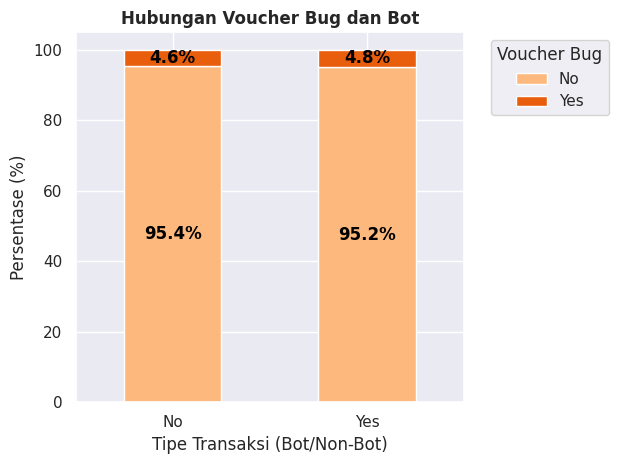

In [ ]:
cross_tab_bot_voucher = pd.crosstab(df_merge_clean['is_bot'], df_merge_clean['voucher_bug'], normalize='index') * 100

plt.figure(figsize=(10, 6))
ax = cross_tab_bot_voucher.plot(kind='bar', stacked=True, color=sns.color_palette('Oranges', 2))

plt.title('Hubungan Voucher Bug dan Bot', fontweight='bold')
plt.xlabel('Tipe Transaksi (Bot/Non-Bot)')
plt.ylabel('Persentase (%)')
plt.xticks(rotation=0)
plt.legend(title='Voucher Bug', bbox_to_anchor=(1.05, 1), loc='upper left')

for container in ax.containers:
    labels = [f'{w:.1f}%' if (w := v.get_height()) > 0 else '' for v in container]
    ax.bar_label(container, labels=labels, label_type='center', color='black', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# Membuat contingency table
contingency_table = pd.crosstab(df_merge_clean['is_bot'], df_merge_clean['voucher_bug'])

print("Contingency Table:")
display(contingency_table)

# Melakukan Chi-square test
chi2, p_value, dof, expected = sc.chi2_contingency(contingency_table)

print(f"\nChi-square statistic: {chi2:.2f}")
print(f"P-value: {p_value:.4f}")
print(f"Degrees of freedom: {dof}")

Contingency Table:


voucher_bug,No,Yes
is_bot,,
No,279876,13397
Yes,3548,179



Chi-square statistic: 0.41
P-value: 0.5207
Degrees of freedom: 1


Kita melihat distribusi transaksi dengan dan tanpa `voucher_bug` untuk bot dan non-bot. Dari tabel ini, terlihat bahwa mayoritas transaksi, baik oleh non-bot maupun bot, tidak mengalami `voucher_bug`.

Namun, untuk secara statistik menguji apakah perbedaan proporsi ini signifikan, kita menggunakan uji Chi-square.

**Hasil Uji Statistik (Chi-square):**

*   **P-value:** `0.5207`

Dengan P-value sebesar 0.5207, yang jauh lebih besar dari tingkat signifikansi umum (misalnya 0.05), kita **tidak dapat menolak hipotesis nol**. Ini berarti **tidak ada bukti statistik yang signifikan** untuk menyimpulkan adanya hubungan antara apakah suatu transaksi dilakukan oleh bot (`is_bot`) dan apakah transaksi tersebut mengalami `voucher_bug`.

Dengan kata lain, berdasarkan data yang ada, kemungkinan terjadinya `voucher_bug` tidak secara signifikan berbeda antara transaksi yang dilakukan oleh bot dan transaksi yang dilakukan oleh non-bot.

## **4. Bagaimana pola durasi checkout (dari masuk keranjang hingga bayar) yang mengindikasikan transaksi tersebut dilakukan oleh bot/script?**

In [ ]:
# Uji Statistik Untuk Memastikan Normal/Tidak Data (Shapiro)
# Jika P-Value < 0.05 (5%) Data Tidak Berdistribusi Normal

stat, pval = sc.shapiro(df_merge_clean['checkout_duration_sec'])

if pval < 0.05 :
  print('Data Tidak Berdistribusi Normal')
else :
  print('Data Berdistribusi Normal')

Data Tidak Berdistribusi Normal


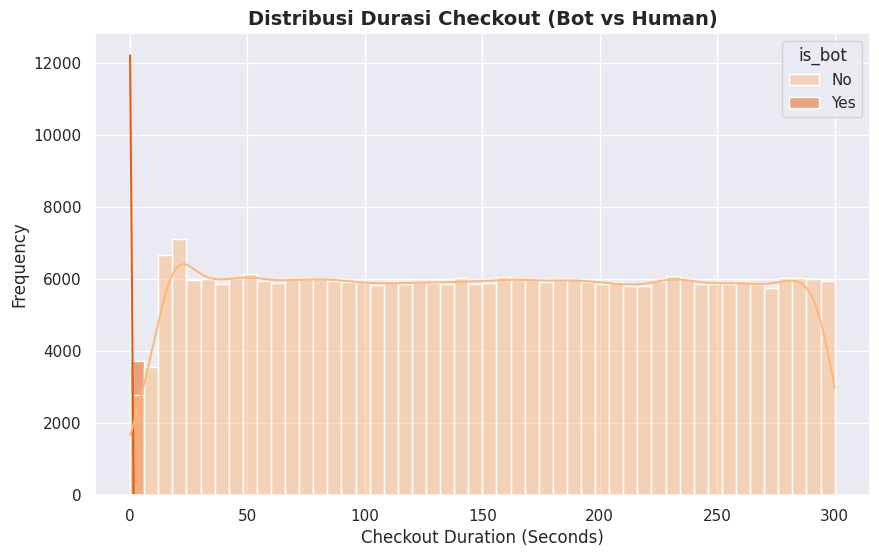

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df_merge_clean, x='checkout_duration_sec', hue='is_bot', bins=50, kde=True, palette='Oranges')
plt.title('Distribusi Durasi Checkout (Bot vs Human)', fontsize=14, fontweight='bold')
plt.xlabel('Checkout Duration (Seconds)')
plt.ylabel('Frequency')
plt.show()

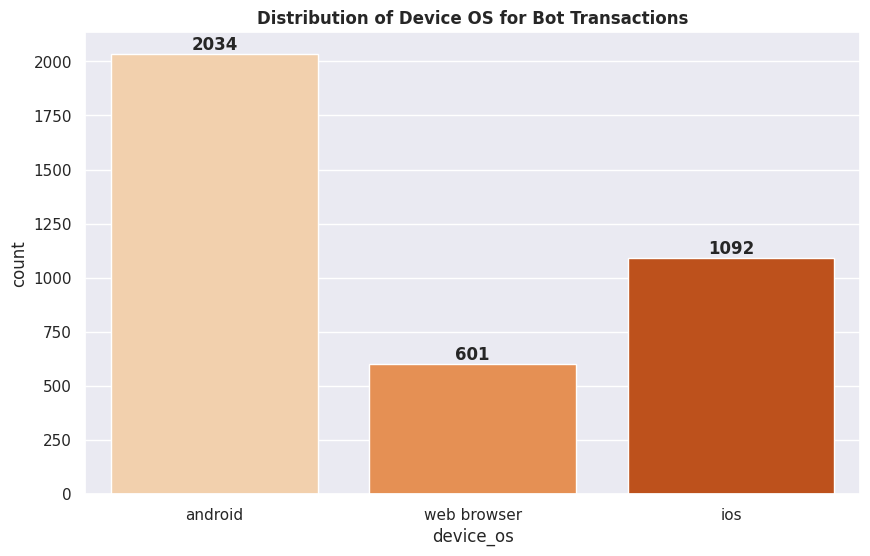

In [ ]:
plt.figure(figsize=(10, 6))
bot_df = df_merge_clean[df_merge_clean['is_bot'] == 'Yes']
ax = sns.countplot(data=bot_df, x='device_os', palette='Oranges')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()), ha='center', va='bottom', fontweight='bold')

plt.title('Distribution of Device OS for Bot Transactions', fontweight='bold')
plt.show()

### **Diagnostic**

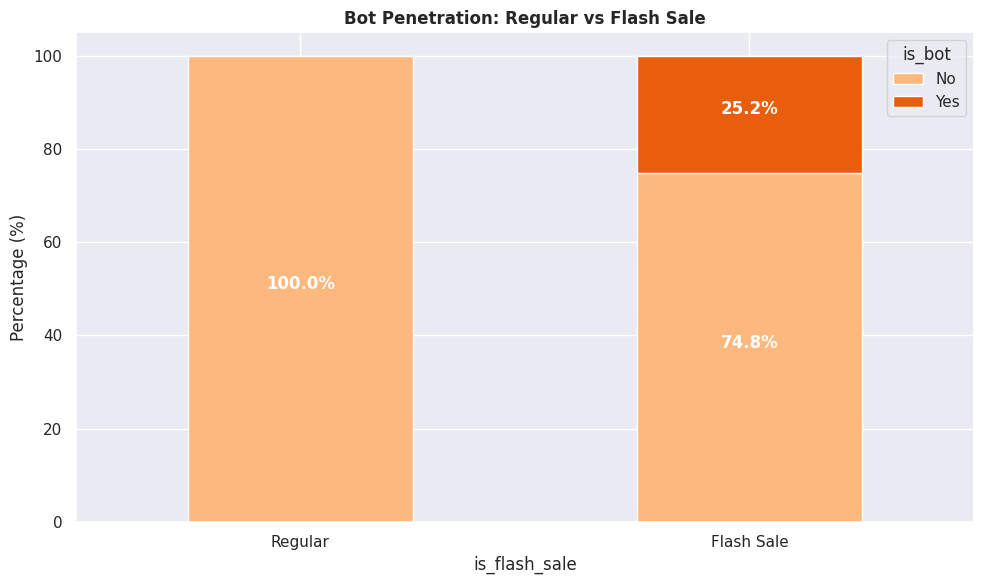

In [ ]:
bot_fs_ratio = pd.crosstab(df_merge_clean['is_flash_sale'], df_merge_clean['is_bot'], normalize='index') * 100
ax = bot_fs_ratio.plot(kind='bar', stacked=True, color=sns.color_palette('Oranges', 2), figsize=(10, 6))

plt.title('Bot Penetration: Regular vs Flash Sale', fontweight='bold')
plt.xticks([0, 1], ['Regular', 'Flash Sale'], rotation=0)
plt.ylabel('Percentage (%)')

# Simple label loop
for p in ax.patches:
    if p.get_height() > 0:
        ax.text(p.get_x() + p.get_width()/2, p.get_y() + p.get_height()/2, f'{p.get_height():.1f}%',
                ha='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

1. **Anomali Durasi Checkout** Bot melakukan checkout sangat cepat (<1 detik), tidak realistis untuk manusia. Sementara itu, transaksi manusia memiliki durasi normal (rata-rata 150 detik).

2. **Bot di Flash Sale**
Bot hanya muncul di Flash Sale dan mencapai 25,2% dari total transaksi, menunjukkan adanya penggunaan skrip otomatis untuk memanfaatkan diskon besar.

3. Perangkat Bot
Mayoritas bot menggunakan Android, disusul iOS, kemungkinan melalui emulator atau perangkat yang dimodifikasi.

Kesimpulan:
Bot secara signifikan mengganggu Flash Sale dengan mengambil porsi besar transaksi, menyebabkan kerugian finansial dan menurunkan kepercayaan pengguna.

## **5. Apakah ada korelasi antara metode pembayaran tertentu (misal: Transfer Bank Manual) dengan tingkat keberhasilan transaksi bot di Flash Sale?**

Analisis ini tidak dapat dilakukan karena tidak ditemukan dataset yang berisi informasi mengenai metode pembayaran.

Untuk analisis fraud yang lebih komprehensif di masa mendatang, sangat disarankan untuk menyertakan data metode pembayaran dalam dataset transaksi.

Informasi ini krusial untuk mengidentifikasi pola-pola fraud yang mungkin memanfaatkan metode pembayaran tertentu dan membantu dalam membangun strategi mitigasi yang lebih efektif.

## **6. Device ID mana saja yang terafiliasi dengan ratusan akun berbeda (indikasi farm account)?**

In [ ]:
# Top 10 Devices with most unique users
farm_accounts = df_merge_clean.groupby('device_id')['user_id'].nunique().nlargest(10)

print("Top 10 Devices indicating Farm Accounts:")
print(farm_accounts)

Top 10 Devices indicating Farm Accounts:
device_id
Unknown      600
DEV-04178      9
DEV-04958      9
DEV-05833      9
DEV-08073      9
DEV-01806      8
DEV-02263      8
DEV-03833      8
DEV-04168      8
DEV-00605      7
Name: user_id, dtype: int64


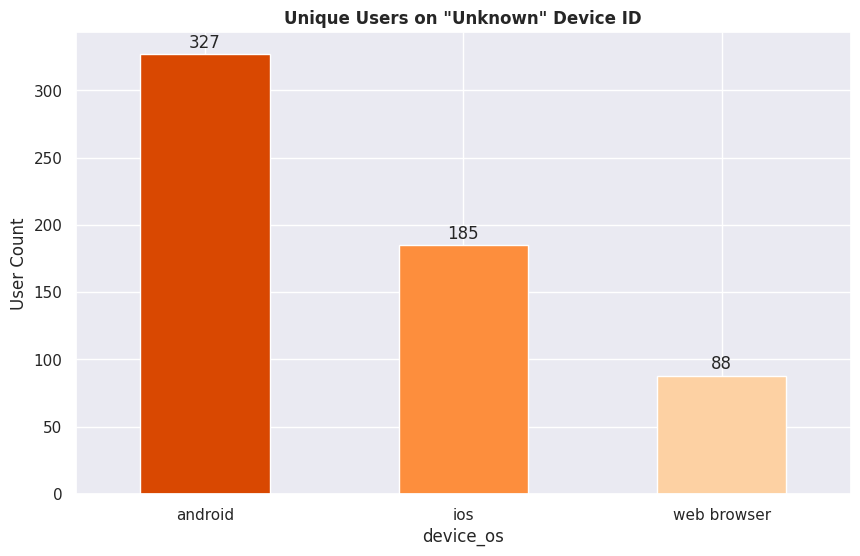

In [ ]:
unknown_stats = df_merge_clean[df_merge_clean['device_id'] == 'Unknown'].groupby('device_os')['user_id'].nunique()

plt.figure(figsize=(10, 6))
# Use the 'color' argument with a list of colors from the 'Oranges' palette
colors = sns.color_palette('Oranges_r', len(unknown_stats))
ax = unknown_stats.plot(kind='bar', color=colors)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height() + 5), ha='center')

plt.title('Unique Users on "Unknown" Device ID', fontweight='bold')
plt.ylabel('User Count')
plt.xticks(rotation=0)
plt.show()

**Device ID 'Unknown':** Ini adalah temuan paling signifikan, di mana 600 *User ID* terkait dengan `device_id` yang 'Unknown'. Hal ini sangat mencurigakan karena ketiadaan identifikasi perangkat dapat mengindikasikan upaya penyembunyian identitas, penggunaan *emulator*, atau *script* otomatis.

Beberapa `device_id` seperti DEV-04178, DEV-05833, DEV-08073, dst. menunjukkan afiliasi dengan 7-9 akun berbeda. Dalam penggunaan normal, satu perangkat jarang digunakan oleh lebih dari 2-3 akun. Ini bisa saja menjadi ciri khas *farm account* yang digunakan untuk mendaftar banyak akun palsu dan mengeksploitasi promo.

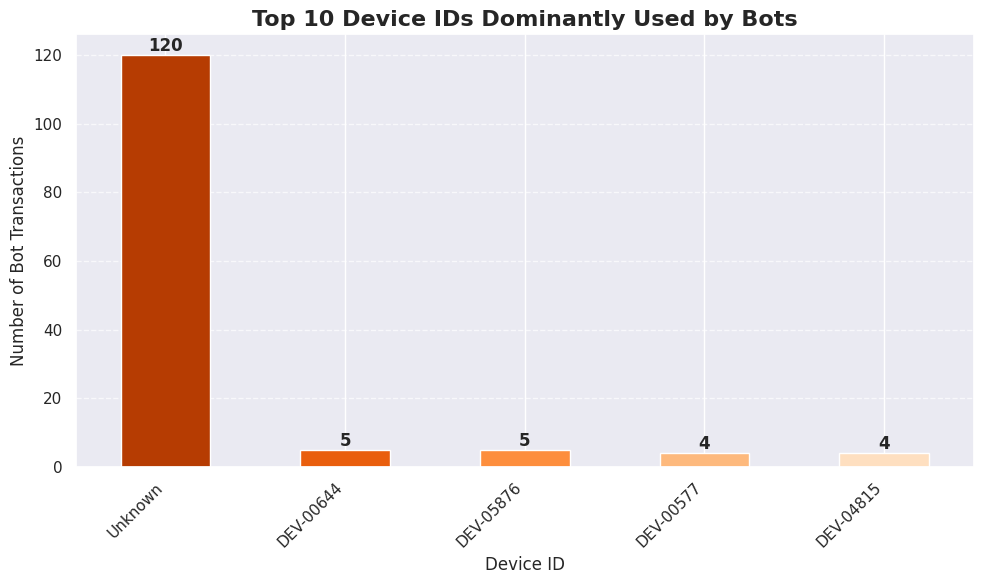

In [ ]:
plt.figure(figsize=(10, 6))

# Filter data for bot transactions
bot_device_counts = df_merge_clean[df_merge_clean['is_bot'] == 'Yes']['device_id'].value_counts().nlargest(5)

ax = bot_device_counts.plot(kind='bar', color=sns.color_palette('Oranges_r', len(bot_device_counts)))

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()), ha='center', va='bottom', fontweight='bold')

plt.title('Top 10 Device IDs Dominantly Used by Bots', fontsize=16, fontweight='bold')
plt.xlabel('Device ID', fontsize=12)
plt.ylabel('Number of Bot Transactions', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Dari analisis `device_id` yang digunakan oleh transaksi bot, terlihat bahwa:

`device_id` 'Unknown' memiliki jumlah transaksi bot terbanyak (120 transaksi). Hal ini sangat mengindikasikan bahwa bot seringkali beroperasi tanpa identifikasi perangkat yang jelas, atau menggunakan metode untuk menyembunyikan identitas perangkat mereka (misalnya, emulator atau skrip yang tidak melaporkan `device_id` dengan benar). Ini adalah anomali yang signifikan dan perlu menjadi fokus investigasi lebih lanjut.

**Kesimpulan**: `device_id` 'Unknown' adalah indikator kuat aktivitas bot yang berupaya menyembunyikan identitas.

# **CONCLUSION & RECOMMENDATION**

## **A. KESIMPULAN ANALISIS**
---

Berdasarkan rangkaian analisis yang telah dilakukan terhadap data transaksi, pengguna, dan voucher, berikut adalah poin-poin kesimpulan utamanya:

1.  **Integritas Data (Device OS):** Sistem awal memiliki pencatatan yang sangat tidak konsisten (9 kategori OS). Setelah standarisasi menjadi **Android, iOS, dan Web Browser**, analisis menjadi lebih akurat dalam memetakan perilaku pengguna.

2.  **Ancaman Bot & Scalper:**
    *   Ditemukan aktivitas bot yang signifikan, terutama pada masa **Flash Sale (25,2% dari total transaksi Flash Sale)**.
    *   Bot ditandai dengan durasi *checkout* yang tidak manusiawi (< 1 detik).
    *   Penggunaan `device_id` **'Unknown'** merupakan indikator kuat bot yang mencoba menyembunyikan identitas perangkat.

3.  **Kebocoran Anggaran Promosi (Voucher & Koin):**
    *   **Voucher Bug:** Terdapat **13.576 transaksi** yang berhasil menggunakan voucher tanpa memenuhi syarat minimum belanja (*Min Spend*), mengakibatkan estimasi kerugian sebesar **Rp 369.883.390**.
    *   **Anomali Koin:** Ditemukan **6.886 transaksi** di mana pengguna bisa menukarkan koin melebihi saldo yang mereka miliki, dengan total kerugian sistem sekitar **Rp 2.553.584**.

4.  **Pola Perangkat (Farm Accounts):**
    *   Adanya indikasi kuat penggunaan *farm accounts* di mana satu perangkat digunakan oleh banyak akun (hingga 9 akun per perangkat).
    *   Perangkat Android mendominasi baik dalam penggunaan normal maupun aktivitas mencurigakan.

**Kesimpulan Akhir:** Platform saat ini menghadapi tantangan serius berupa eksploitasi promo oleh bot dan adanya celah (*bug*) validasi pada sistem *checkout*. Perbaikan sistem validasi *server-side* dan pengetatan keamanan pada periode Flash Sale sangat mendesak dilakukan untuk menyelamatkan anggaran pemasaran perusahaan.

## **B. REKOMENDASI STRATEGIS (Actionable Plan)**
---

Berdasarkan temuan analisis, berikut adalah langkah-langkah yang direkomendasikan untuk tim manajemen dan operasional:

1.  **Proteksi Flash Sale dengan Tantangan (Challenge):**
    *   Mengingat **25,2%** transaksi Flash Sale dikuasai bot, wajibkan verifikasi tambahan seperti **CAPTCHA** atau tantangan biometrik khusus untuk produk Flash Sale yang habis dalam < 1 detik.

2.  **Audit dan Perbaikan Validasi Server-Side:**
    *   **Voucher:** Perbaiki logika sistem agar tidak mengizinkan pemotongan harga jika `total_amount` belum mencapai `min_spend`. Hal ini berpotensi menyelamatkan anggaran promosi hingga ratusan juta rupiah.
    *   **Koin:** Tambahkan validasi *real-time* yang memastikan jumlah koin yang ditukarkan tidak boleh melebihi saldo akun pengguna.

3.  **Kebijakan Pembatasan Akun Per Perangkat:**
    *   Terapkan kebijakan **'Satu Perangkat, Maksimal 3 Akun'**. Jika sebuah `device_id` terdeteksi login dengan lebih dari 3 akun unik, berikan penanda (*flagging*) untuk ditinjau secara manual atau blokir akses akun tersebut dari program subsidi (voucher/koin).

4.  **Peningkatan Kualitas Identifikasi Perangkat:**
    *   Perbarui SDK pelacakan perangkat untuk meminimalkan status `device_id` 'Unknown'. Identitas perangkat yang jelas adalah kunci utama dalam memblokir *emulator* dan skrip bot.

5.  **Penyertaan Data Metode Pembayaran:**
    *   Untuk analisis mendatang, tambahkan kolom **metode pembayaran**. Hal ini krusial untuk melihat apakah bot cenderung menggunakan metode tertentu (seperti transfer bank manual) yang mungkin memiliki celah validasi pembayaran.